COMPARISON OF NORMAL AND STUDENT DISTRIBUTION
==========================================================================

In [ ]:
#import of libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

import scipy.stats as stats
from scipy.stats import norm, t, jarque_bera

warnings.filterwarnings("ignore")
plt.style.use("default")

In [ ]:
#import of data and data munging
apple=pd.read_csv("apple.csv")
apple["Date"]=pd.to_datetime(apple["Date"])
apple.set_index("Date",inplace=True)
apple.sort_index(inplace=True)

#Calibrate on 2006-2007 calm period
apl=apple["2006-10-02":"2007-10-02"].dropna()
print(apl.head())
print("")
print(apl.tail())

                 Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2006-10-02  10.728572  10.838572  10.614285  10.694285   7.239566  178159800
2006-10-03  10.635715  10.707143  10.455714  10.582857   7.164135  197677200
2006-10-04  10.585714  10.780000  10.451428  10.768572   7.289855  207270700
2006-10-05  10.647142  10.880000  10.590000  10.690000   7.236666  170970800
2006-10-06  10.631429  10.720000  10.544286  10.602858   7.177672  116739700

                 Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2007-09-26  22.067142  22.142857  21.607143  21.824286  14.774095  243817000
2007-09-27  21.967142  22.074286  21.760000  22.071428  14.941398  164549700
2007-09-28  21.920000  22.085714  21.821428  21.924286  14.841787  153775300
2007-10-01  22.090000  22.487143  21.847143  22.334286  15.119342  20926710

mean mu=0.00 and volatility sigma=0.02


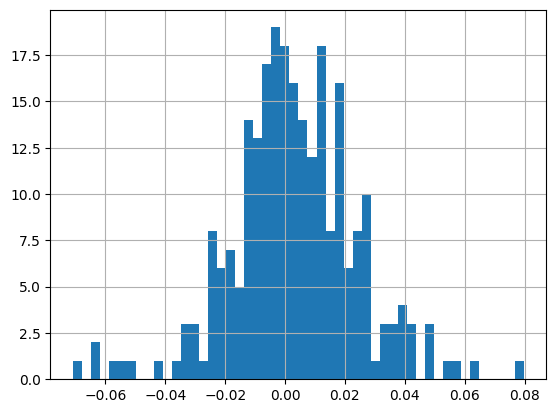

In [68]:
#determine logreturn, its visualisation, mean mu, volatility sigma
apl["logreturn"]=np.log(apl["Close"]/apl["Close"].shift(1))
mu=apl["logreturn"].mean()
sigma=apl["logreturn"].std(ddof=1)
apl["logreturn"].hist(bins=50)
print(f"mean mu={mu:.2f} and volatility sigma={sigma:.2f}")

Com: logreturns histogram looks like bell, mean mu=0.00 and  volatility sigma=0.02
-->so we suppose that the distribution is normal

In [69]:
#determine density function pdf and cumulative function cdf and their visualisation, 
#calcul value at risk at 95% and its visualisation and expected shortfall ES
denapl=pd.DataFrame()
denapl["x"]=np.arange(-0.1,0.1,0.001)
denapl["PDF_norm"]=norm.pdf(denapl["x"],mu,sigma)
denapl["CDF_norm"]=norm.cdf(denapl["x"],mu,sigma)
alpha=0.05
VaR95_norm=norm.ppf(alpha,mu,sigma)
ES=mu-sigma*norm.pdf(norm.ppf(0.05))/alpha
print(f"normal Value at risk={VaR95_norm:.2f} and expected shortfall ES={ES:.2f}")

normal Value at risk=-0.03 and expected shortfall ES=-0.04


In [70]:
#Backtesting on crise year 2008, supposing the distribution is normal
apl08=apple["2007-12-31":"2008-12-31"].dropna()
apl08["logreturn"]=(np.log(apl08["Close"]/(apl08["Close"].shift(1)))).dropna()
apl08["violation"]=apl08["logreturn"]<VaR95_norm
nb_day=len(apl08)
nb_violation=apl08["violation"].sum()
violation_rate=(nb_violation/nb_day)*100
expected_rate=5 
print("==========normal backtest==========")
print(f"""number of trading day={nb_day:.2f}
number of violation={nb_violation:.2f}
violation rate={violation_rate:.2f}%
expected rate={expected_rate:.2f}%""")
#-->Output: normal violation rate=18.5%>expected rate=5%
if violation_rate>5:
    print(f"""violation rate={violation_rate:.2f}% > 5%,
          --> so the normal distribution under-estimate the risk""")
else:
      print("the normal distribution is adapted to these returns")
print("="*35)
print("")


==========normal backtest==========
number of trading day=254.00
number of violation=47.00
violation rate=18.50%
expected rate=5.00%
violation rate=18.50% > 5%,
          --> so the normal distribution under-estimate the risk



Com: the normal distribution under-estimate the risk. We are going to verify about fat tails

jb stats=24.81 and jb_pvalue =0.00


((array([-2.77656829, -2.4747255 , -2.30335476, -2.18099319, -2.0845634 ,
         -2.00433695, -1.93525503, -1.87433666, -1.81967137, -1.76995825,
         -1.72426993, -1.68192103, -1.64239011, -1.60527085, -1.5702402 ,
         -1.53703691, -1.50544658, -1.47529098, -1.44642028, -1.41870723,
         -1.39204287, -1.36633307, -1.34149598, -1.31745993, -1.29416181,
         -1.27154575, -1.249562  , -1.2281661 , -1.20731813, -1.1869821 ,
         -1.16712546, -1.14771863, -1.1287347 , -1.11014907, -1.0919392 ,
         -1.0740844 , -1.05656561, -1.03936522, -1.02246696, -1.00585573,
         -0.98951752, -0.97343927, -0.9576088 , -0.94201475, -0.92664647,
         -0.911494  , -0.89654796, -0.88179957, -0.86724053, -0.85286303,
         -0.83865971, -0.82462359, -0.81074809, -0.79702695, -0.78345425,
         -0.77002437, -0.75673195, -0.74357192, -0.73053942, -0.71762984,
         -0.70483876, -0.69216198, -0.67959546, -0.66713536, -0.65477799,
         -0.64251981, -0.63035742, -0.

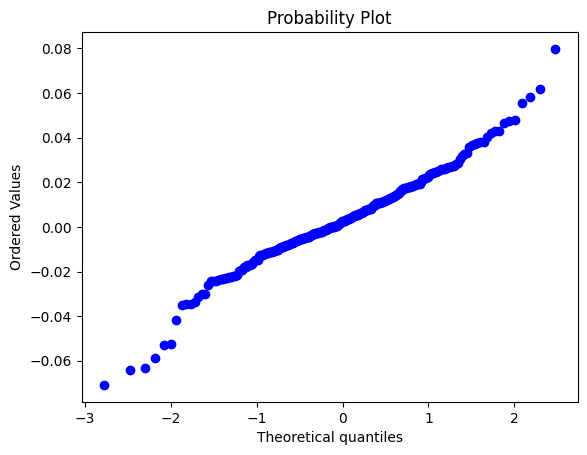

In [78]:
#verify if there are fat tails
#jarque_bera
jb_stats,jb_pvalue=stats.jarque_bera(apl["logreturn"].dropna())
print(f"jb stats={jb_stats:.2f} and jb_pvalue ={jb_pvalue:.2f}")
#qq-plot
stats.probplot(apl["logreturn"], dist="norm", plot=plt)

Com: jb stats=24.81 and pvalue=0.00<0.5
+
qqplot lokks like S ===> there are fat tails

In [72]:
#choice of the good distribution
#kurtosis
kurt_exces=apl["logreturn"].kurtosis()
print(f"kurtosis excess ={kurt_exces:.2f} so kurtosis is {kurt_exces+3:.2f}")

kurtosis excess =1.58 so kurtosis is 4.58


Com: kurtosis is 4.58 so the adeuqate distribution is student one

In [73]:
#Calibrate student distribution
ld,loc_t,scale_t=stats.t.fit(apl["logreturn"].dropna())
VaR95_t=t.ppf(alpha,ld,loc_t,scale_t)
z=VaR95_t
ES_t=loc_t+scale_t*(-t.pdf(z,ld)/alpha)*(ld+z**2)/(ld-1)
print(f"student VaR95={VaR95_t:.2f} and expected shortfall={ES_t:.2f}")

student VaR95=-0.03 and expected shortfall=-0.16


In [74]:
#Student backtest on 2008 crisis year
apl08["t_violation"]=apl08["logreturn"]<VaR95_t
nb_t_violation=apl08["t_violation"].sum()
t_violation_rate=(nb_t_violation/nb_day)*100
print("")
print("==========student Backtest==========")
print(f"""number of trading day={nb_day}
number of student violation={nb_t_violation:.2f}
student violation rate={t_violation_rate:.2f}%
expectedet rate=5%""")
print("="*36)


==========student Backtest==========
number of trading day=254
number of student violation=49.00
student violation rate=19.29%
expectedet rate=5%


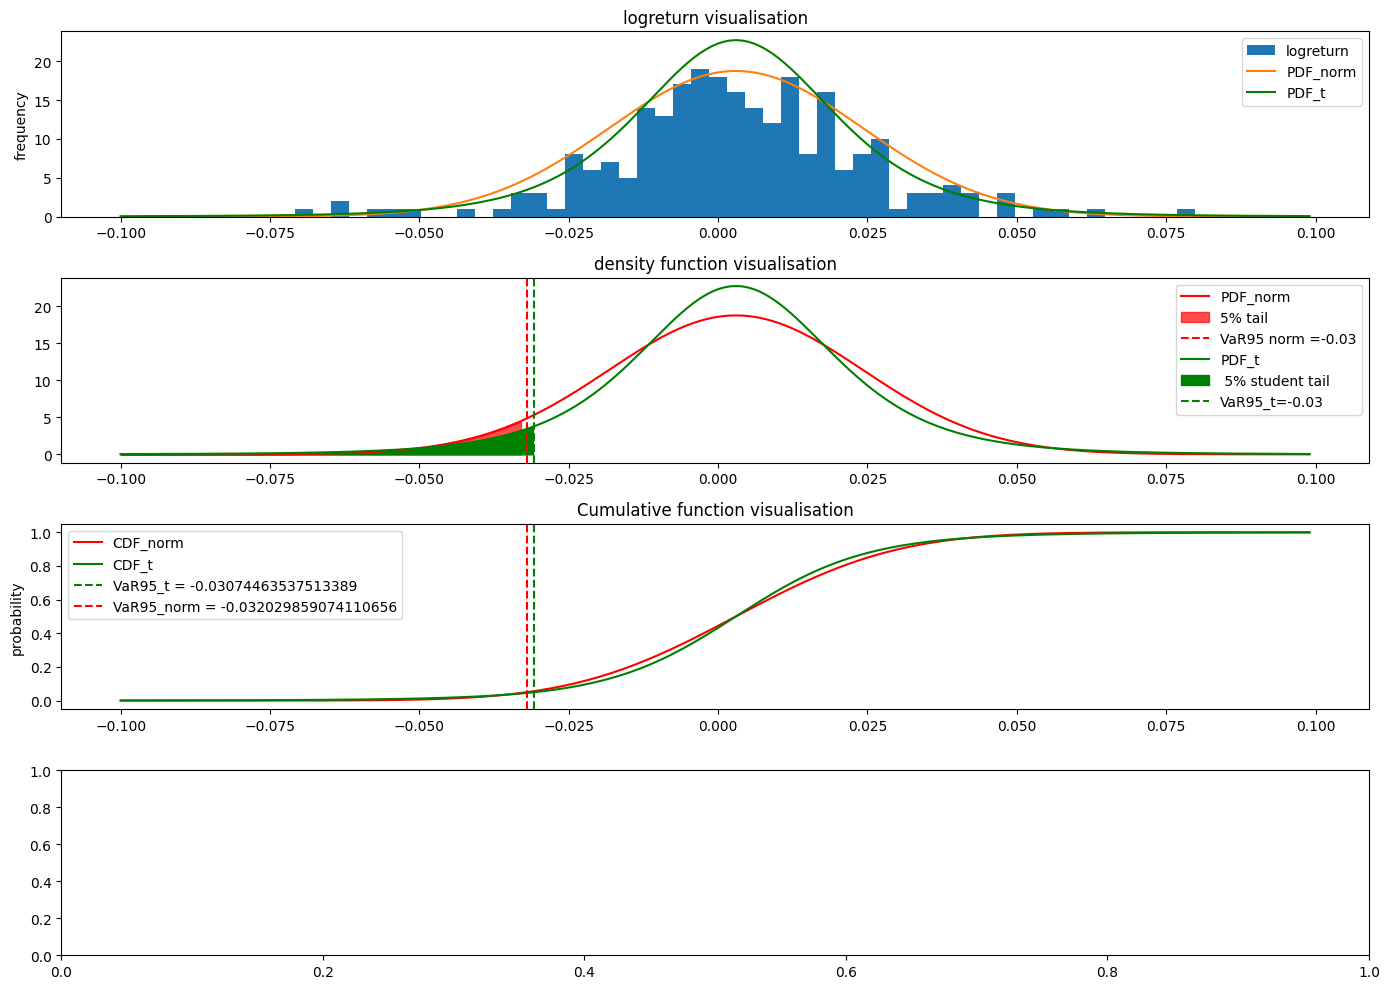

In [75]:
#visualisation
fig,(axe1,axe2,axe3,axe4)=plt.subplots(4,1,figsize=(14,10))
#logreturn visualisation
apl["logreturn"].plot(ax=axe1,label="logreturn",alpha=1,kind='hist', bins=50)
axe1.plot(denapl["x"],denapl["PDF_norm"],label="PDF_norm")
axe1.set_title("logreturn visualisation")
axe1.set_ylabel("frequency")
axe1.legend(loc="best")
#probability density function visualisation
axe2.plot(denapl["x"],denapl["PDF_norm"],label="PDF_norm",color="red")
axe2.fill_between(denapl["x"],denapl["PDF_norm"], where=(denapl["x"]<=VaR95_norm),
                  color="red",label="5% tail", alpha=0.7)
axe2.axvline(VaR95_norm, linestyle="--", color="red", label=f"VaR95 norm ={VaR95_norm:.2f}")
axe2.set_title("density function visualisation")
axe2.legend(loc="best")
#Cumulative density function visualisation
axe3.plot(denapl["x"],denapl["CDF_norm"],label="CDF_norm", color="red")
axe3.set_title("Cumulative function visualisation")
axe3.set_ylabel("probability")
axe3.legend(loc="best")

#visualisation
denapl["CDF_t"]=t.cdf(denapl["x"],ld,loc_t,scale_t)
denapl["PDF_t"]=t.pdf(denapl["x"],ld,loc_t,scale_t)
axe1.plot(denapl["x"],denapl["PDF_t"],label="PDF_t", color="green")
axe1.legend()
axe2.plot(denapl["x"],denapl["PDF_t"],label="PDF_t", color="green")
axe2.fill_between(denapl["x"],denapl["PDF_t"], where=(denapl["x"]<=VaR95_t),
                  color="green", label=" 5% student tail")
axe2.axvline(VaR95_t,linestyle="--",color="green", label=f"VaR95_t={VaR95_t:.2f}")
axe2.legend()

axe3.plot(denapl["x"],denapl["CDF_t"],color="green",label="CDF_t")
axe3.axvline(VaR95_t,linestyle="--", color="green",label=f"VaR95_t = {VaR95_t}")
axe3.axvline(VaR95_norm,linestyle="--", color="red", label=f"VaR95_norm = {VaR95_norm}")
axe3.legend()


plt.tight_layout()
plt.show()

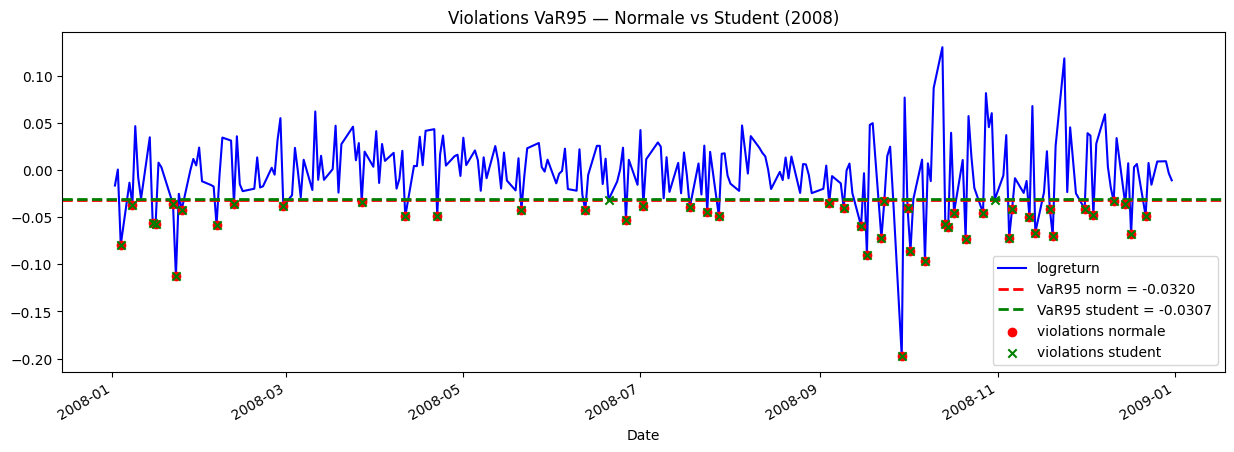

In [76]:
#normal vs student backtest visualisation

apl08["violation_norm"] = apl08["logreturn"] < VaR95_norm
apl08["violation_t"] = apl08["logreturn"] < VaR95_t

fig, ax = plt.subplots(figsize=(15,5))
apl08["logreturn"].plot(ax=ax, label="logreturn", color="blue", alpha=1)

ax.axhline(VaR95_norm, lw=2, color="red", linestyle="--", label=f"VaR95 norm = {VaR95_norm:.4f}")
ax.axhline(VaR95_t, lw=2, color="green", linestyle="--", label=f"VaR95 student = {VaR95_t:.4f}")

ax.scatter(apl08.index[apl08["violation_norm"]], 
           apl08.loc[apl08["violation_norm"], "logreturn"], 
           color="red", label="violations normale", zorder=3)

ax.scatter(apl08.index[apl08["violation_t"]], 
           apl08.loc[apl08["violation_t"], "logreturn"], 
           color="green", marker="x", label="violations student", zorder=4)

ax.set_title("Violations VaR95 — Normale vs Student (2008)")
ax.legend()
plt.show()

Conclusion:

at 95% (VaR95): both are roughly equivalent (-0.032 vs -0.031), Student doesn't bring much here, and even appears slightly "less conservative."


In the true extreme tail (ES, or VaR99): Student captures the risk much better (-0.16 vs -0.04). This is where the Jarque-Bera test (fat tails confirmed) and the kurtosis=4.58 (vs 3 for normal) translate concretely into the results.